# Objectius: Influència del cost mensual i el temps d'estada a la companyia

Un cop hem analitzat en profunditat les variables dels fitxers CSV toca centrar-nos en els propis objectius de l'anàlisi. En aquest cas veurem si hi ha certa influència dels preus dels serveis que els clients paguen mes a mes i si aquests, en conseqüència, abandonen. No és necessari que trobem una relació directa, però sí si influeix d'alguna forma.

Carreguem les biblioteques que utilitzarem al llarg del notebook.


In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Carreguem el fitxer CSV `abandonament_editat`, ja que és el que conté les dades sobre els abandonaments i també sobre les despeses mensuals d'aquests clients.

In [105]:
df_aband=pd.read_csv('abandonament_editat.csv')

Primer de tot fem dos grans grups de clients, aquells que han abandonat i aquells que no ho han fet.

In [107]:
df_si_aband=df_aband[df_aband['Churn']=='Yes']
df_no_aband=df_aband[df_aband['Churn']=='No']

Mirem que no hi hagi cap error. Amb les dades obtingudes a l'anàlisi de variables sabem que el dataframe `df_si_aband` ha de tenir 1869 files i l'altre dataframe ha de tenir 5173 clients. 

In [109]:
df_si_aband.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1869 entries, 2 to 7041
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1869 non-null   int64  
 1   customerID        1869 non-null   object 
 2   tenure            1869 non-null   int64  
 3   PhoneService      1869 non-null   object 
 4   Contract          1869 non-null   object 
 5   PaperlessBilling  1869 non-null   object 
 6   PaymentMethod     1869 non-null   object 
 7   MonthlyCharges    1869 non-null   float64
 8   TotalCharges      1869 non-null   float64
 9   Churn             1869 non-null   object 
 10  AutomaticPayment  1869 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 175.2+ KB


In [110]:
df_no_aband.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5173 entries, 0 to 7040
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5173 non-null   int64  
 1   customerID        5173 non-null   object 
 2   tenure            5173 non-null   int64  
 3   PhoneService      5173 non-null   object 
 4   Contract          5173 non-null   object 
 5   PaperlessBilling  5173 non-null   object 
 6   PaymentMethod     5173 non-null   object 
 7   MonthlyCharges    5173 non-null   float64
 8   TotalCharges      5173 non-null   float64
 9   Churn             5173 non-null   object 
 10  AutomaticPayment  5173 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 485.0+ KB


Veiem com tot està en ordre.

Mirem com eren els costs mensuals per als clients que han abandonat l'empresa de telecomunicacions. 

In [113]:
df_si_aband['MonthlyCharges'].describe()

count    1869.000000
mean       74.441332
std        24.666053
min        18.850000
25%        56.150000
50%        79.650000
75%        94.200000
max       118.350000
Name: MonthlyCharges, dtype: float64

Mirem el dels que continuen a l'empresa. 

In [115]:
df_no_aband['MonthlyCharges'].describe()

count    5173.000000
mean       61.256544
std        31.089527
min        18.250000
25%        25.100000
50%        64.400000
75%        88.400000
max       118.750000
Name: MonthlyCharges, dtype: float64

Veiem que per als que han abandonat, els pagaments mensuals eren una mica més elevats comparats amb els que tenen els que encara no han abandonat. 

Fem dos boxplots (un per cada grup) per veure on es troben la majoria de clients pel que fa a costs mensuals. És a dir comprovar de forma gràfica que paguen la major part de persones d'un grup determinat. 

Cost mensual de clients que abandonen:

Text(0.5, 0, 'Cost (suposem €)')

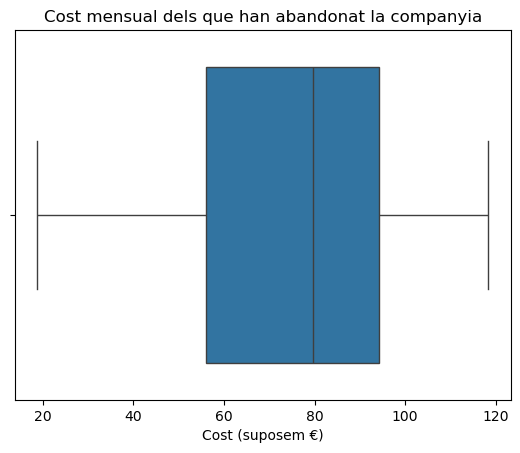

In [118]:
sns.boxplot( x = df_si_aband['MonthlyCharges'])
plt.title('Cost mensual dels que han abandonat la companyia')
plt.xlabel('Cost (suposem €)')

Cost mensual de clients que continuen:

Text(0.5, 0, 'Cost (suposem €)')

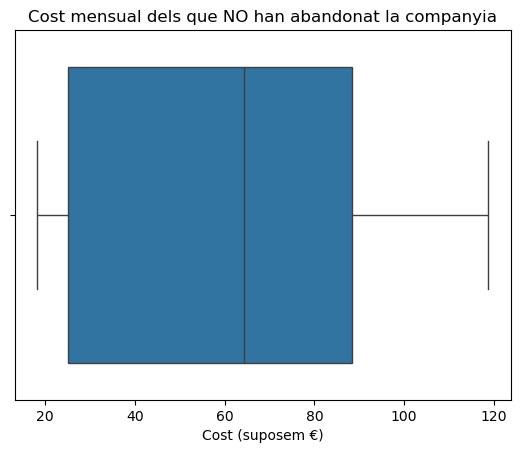

In [120]:
sns.boxplot( x = df_no_aband['MonthlyCharges'])
plt.title('Cost mensual dels que NO han abandonat la companyia')
plt.xlabel('Cost (suposem €)')

>Veiem que clarament, aquells clients que SI han abandonat l'empresa de telecomunicacions pagaven quotes mensuals bastant més elevades en comparació amb els que hi continuen. 
>
>Amb aquestes dades podem dir que sí que existeix una certa influència dels preus que paguen els clients amb l'abandonament d'aquests. Quant més preu paguen més tendeixen a abandonar. 


També pot estar interessant veure si no solament aquesta tendència a l'abandonament està relacionada amb el que paguen els clients cada mes sinó que també durant quant de temps ho han estat fent. És possible que aquells que fa molts mesos que paguen una quota elevada siguin més propensos a abandonar que aquells que hi porten menys temps.

Per fer-ho, crearem un gràfic de barres amb diferents franges de mesos de permanència en orde creixent. Així mateix cada franja contindrà dues barres, una que indiqui la quantitat de persones que han abandonat l'empresa de telecomunicacions i altra amb la mitjana de costos mensuals a cada franja.

Creem una nova columna al dataframe en funció de les franges de permanència (hi ha permanències fins a 72 mesos, fem 8 franges de 9 mesos cadascuna). Com que també hi ha clients que han estat 0 mesos l'última franja tindrà un mes més.

In [125]:
df_aband['Franja__mesos_permanencia']=df_aband['tenure']
for i in range(len(df_aband)):
    if (0 <= df_aband.loc[i,'tenure'] < 9) :
        df_aband.loc[i,'Franja__mesos_permanencia']='0-08'
    elif (9 <= df_aband.loc[i,'tenure'] < 18) :
        df_aband.loc[i,'Franja__mesos_permanencia']='09-17'
    elif (18 <= df_aband.loc[i,'tenure'] < 27) :
        df_aband.loc[i,'Franja__mesos_permanencia']='18-26'
    elif (27 <= df_aband.loc[i,'tenure'] < 36 ) :
        df_aband.loc[i,'Franja__mesos_permanencia']='27-35'
    elif (36 <= df_aband.loc[i,'tenure'] < 45) :
        df_aband.loc[i,'Franja__mesos_permanencia']='36-44'
    elif (45 <= df_aband.loc[i,'tenure'] < 54) :
        df_aband.loc[i,'Franja__mesos_permanencia']='45-53'
    elif (54 <= df_aband.loc[i,'tenure'] < 63) :
        df_aband.loc[i,'Franja__mesos_permanencia']='54-62'
    elif (63 <= df_aband.loc[i,'tenure'] <= 72) :
        df_aband.loc[i,'Franja__mesos_permanencia']='63-72'  

C:\Users\oscar\AppData\Local\Temp\ipykernel_52456\658131491.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0-08' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_aband.loc[i,'Franja__mesos_permanencia']='0-08'


Comprovem si ha funcionat.

In [127]:
df_aband['Franja__mesos_permanencia'].value_counts()

Franja__mesos_permanencia
0-08     1735
63-72    1260
09-17     902
18-26     731
54-62     626
27-35     624
45-53     619
36-44     545
Name: count, dtype: int64

Veiem que no hi ha cap valor nul i per tant totes les files tenen la seva franja.

Ara fem un `groupby()` per les franges i així podem veure les estadístiques de cada franja de forma més fàcil i també fer el gràfic descrit anteriorment.

C:\Users\oscar\AppData\Local\Temp\ipykernel_52456\4089346735.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Perc_aband_si['0-08']=t1[0]
C:\Users\oscar\AppData\Local\Temp\ipykernel_52456\4089346735.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Perc_aband_si['09-17']=t2[1]
C:\Users\oscar\AppData\Local\Temp\ipykernel_52456\4089346735.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Perc_aband_si['18-26']=t3[1]
C:\Users

Text(0.5, 0, 'Mesos')

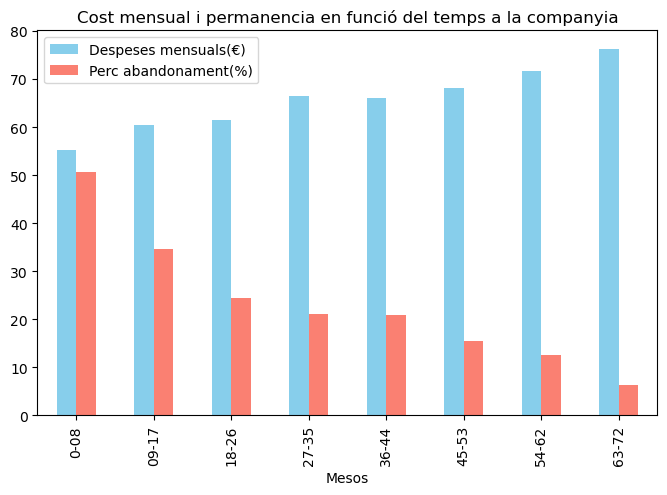

In [130]:
g=df_aband.groupby('Franja__mesos_permanencia')

m_cost=g['MonthlyCharges'].mean()
Perc_aband=g['Churn'].value_counts(normalize=True)*100
t1=Perc_aband.loc['0-08']
t2=Perc_aband.loc['09-17']
t3=Perc_aband.loc['18-26']
t4=Perc_aband.loc['27-35']
t5=Perc_aband.loc['36-44']
t6=Perc_aband.loc['45-53']
t7=Perc_aband.loc['54-62']
t8=Perc_aband.loc['63-72']
Perc_aband_si=g['MonthlyCharges'].mean()
Perc_aband_si['0-08']=t1[0]
Perc_aband_si['09-17']=t2[1]
Perc_aband_si['18-26']=t3[1]
Perc_aband_si['27-35']=t4[1]
Perc_aband_si['36-44']=t5[1]
Perc_aband_si['45-53']=t6[1]
Perc_aband_si['54-62']=t7[1]
Perc_aband_si['63-72']=t8[1]
Perc_aband_si=Perc_aband_si.rename('Perc abandonament(%)')
m_cost=m_cost.rename('Despeses mensuals(€)')
df_nou=pd.concat([m_cost, Perc_aband_si], axis=1)
df_nou.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'salmon'])
plt.title('Cost mensual i permanencia en funció del temps a la companyia')
plt.xlabel('Mesos')

>Com podem observar, clarament no hi ha relació entre haver estat molt de temps a la companyia de telecomunicacions pagant preus elevats i l'abandonament d'aquesta. Segons el gràfic veiem una tendència contrària, el preu mensual va creixent amb el temps, però la proporció de gent que abandona la companyia decreix dràsticament amb el temps. Amb això ens adonem que no tan sols no hi ha proves sòlides de la relació entre pagar preus alts durant molt de temps i l'abandonament sinó que a més descobrim una tendència molt clara relacionada amb la variable de durada a l'empresa (`tenure`) i l'abandonament.
>
>Així veiem que cuant menys temps porten els clients a la companyia, més tendencia a abandonarla. Paral·lelament, cuant més temps porten menys abandonen l'empresa. Cal observar que la mitgana de despeses mensuals és més elevada en clients que porten molt de temps, una posible explicació es que les empreses podrien estar aprofitant-se s'aquesta "fidelitat" que presenten els clients veterans. Tot i això, anteriorment s'ha vist que de mitjana els clients que abandonen la companyia solien pagar més que els que no l'han abandonada independenment del temps que portassin


## Aprofundiment i millora de l'objectiu

Reflexionant una mica ens hem adonat que pot ser les conclusions estretes a l'apartat anterior manquen parcialment de justificació. És a dir, no hem indagat en perquè realment creixen els preus en funció del temps i hem suposat que ho fa la companyia intencionadament quan no té per què ser així. També altre punt a destacar és que sí que hem vist com influeix el temps d'estada en la permanència dels clients, però no si influeix el fet de haver estat pagant quotes altes durant molt de temps en l'abandonament, que era l'objectiu principal. Solament hem vist que de mitjana es paga més quant més de temps es porta, però sense aprofundir si ho fan tots els clients, solament els que abandonen o si solament els que es queden. 

Per aquests motius a continuació intentarem polir una mica més aquest objectiu amb els punts presentats anteriorment. 

- Per què es paga més quant més s'està a la companyia?

Per tenir arguments de pes per veure aquesta clara tendència, hem decidit estudiar els serveis contractats al llarg del temps pels clients i si aquests són el motiu pel qual paguen més. 

Per fer-ho, primer de tot estudiarem el fitxer "internet.csv", que conté tots els serveis que ofereix la companyia i si els clients els han contractat o no. Hem decidit que el més intel·ligent seria afegir una nova columna a aquest fitxer on per cada client es recompta quants serveis té contractats i d'aquesta forma veure més fàcilment que influencia té el preu pagat per cadascun i en quant de temps porten. 

In [137]:
df_serveis=pd.read_csv('internet.csv')

L'objectiu per fer el recompte és aplicar una funció a cada fila que recompti un cert string (les cel·les d'aquest fitxer estan formades enterament per aquests). Gràcies a l'anàlisi previ de les variables d'aquest fitxer sabem que hi ha columnes que tenen simplement `Yes` i `No`, i que n'hi ha d'altres que tenen altres string que equivalen al `No`, per aquest motiu primer editarem el dataframe substituint aquests altres strings per `No` i així serà molt més fàcil el recompte. 

In [139]:
df_serveis=df_serveis.replace('No phone service','No')
df_serveis=df_serveis.replace('No internet service','No')

Fem el recompte.

In [165]:
def f (x):
    return ((x!='No').sum()-2)
df_serveis['serveis_contractats']=df_serveis.apply(f,axis=1)
df_serveis

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,serveis_contractats
0,7590-VHVEG,No,DSL,No,Yes,No,No,No,No,2
1,5575-GNVDE,No,DSL,Yes,No,Yes,No,No,No,3
2,3668-QPYBK,No,DSL,Yes,Yes,No,No,No,No,3
3,7795-CFOCW,No,DSL,Yes,No,Yes,Yes,No,No,4
4,9237-HQITU,No,Fiber optic,No,No,No,No,No,No,1
...,...,...,...,...,...,...,...,...,...,...
7037,2569-WGERO,No,No,No,No,No,No,No,No,0
7038,6840-RESVB,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,7
7039,2234-XADUH,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,6
7040,4801-JZAZL,No,DSL,Yes,No,No,No,No,No,2


Veiem que ha funcionat, ara incorporem aquesta columna al dataframe d'abandonament per fer més facil l'estudi.

In [168]:
df_aband['serveis_contractats']=df_serveis['serveis_contractats']

Representem juntament amb el preu mensual en funció de la franja de mesos com anteriorment (amb el groupby). Com que el número de serveis contractats per client són números entre 0 i 8, per fer més fàcil la visualització a la gràfica amb la mitjana de costos mensuals (que són valors entre 50 i 80) multiplicarem per 10 la mitja de serveis contractats. 

Text(0.5, 0, 'Mesos')

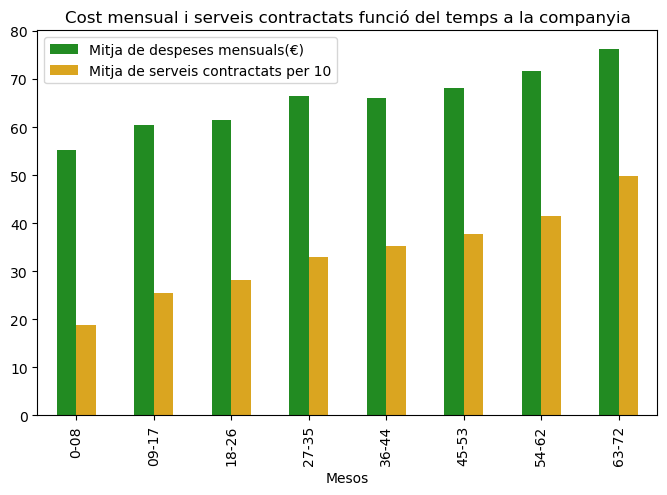

In [182]:
g=df_aband.groupby('Franja__mesos_permanencia')
m_serveis_contr=g['serveis_contractats'].mean()*10
m_cost=g['MonthlyCharges'].mean()
m_serveis_contr=m_serveis_contr.rename('Mitja de serveis contractats per 10')
m_cost=m_cost.rename('Mitja de despeses mensuals(€)')
df_nou=pd.concat([m_cost,m_serveis_contr], axis=1)
df_nou.plot(kind='bar', figsize=(8, 5), color=['forestgreen', 'goldenrod'])
plt.title('Cost mensual i serveis contractats funció del temps a la companyia')
plt.xlabel('Mesos')

>Com es pot observar sí que hi ha una clara influència dels serveis contractats amb les despeses mensuals dels clients. Veiem que quant més de temps porten els clients a la companyia, més serveis tenen contractats i a l'hora, com ja hem vist anteriorment, el cost mensual augmenta. Per tant, podem suposar amb molta confiança que el motiu pel qual augmenta la quantitat mensual a pagar dels clients al llarg del temps és que cada cop contracten més serveis. 

- Com influeix haver estat pagant elevats costos durant molt de temps i l'abandonament?

Ara millorarem i aprofundirem en l'objectiu que vam estudiar anteriorment. El que farem serà veure com s'han comportat les despeses mensuals al llarg del temps, però en aquest cas amb dos grups, aquells que han abandonat i aquells que no ho han fet. 

El més sensat és fer dos gràfics amb el cost mensual en funció del temps i comparar d'aquesta forma els dos casos.

Cas 1: Aquells que SÍ han abandonat:

Text(0.5, 0, 'Mesos')

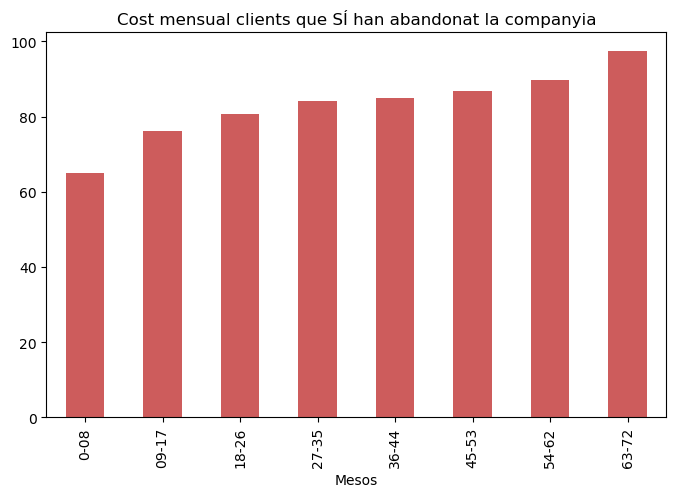

In [195]:
df_si_aband=df_aband[df_aband['Churn']=='Yes']
g1=df_si_aband.groupby('Franja__mesos_permanencia')
m_cost_si_aband=g1['MonthlyCharges'].mean()
m_cost_si_aband.plot(kind='bar', figsize=(8, 5), color='indianred')
plt.title('Cost mensual clients que SÍ han abandonat la companyia')
plt.xlabel('Mesos')

Cas 2: Clients que NO han abandonat la companyia:

Text(0.5, 0, 'Mesos')

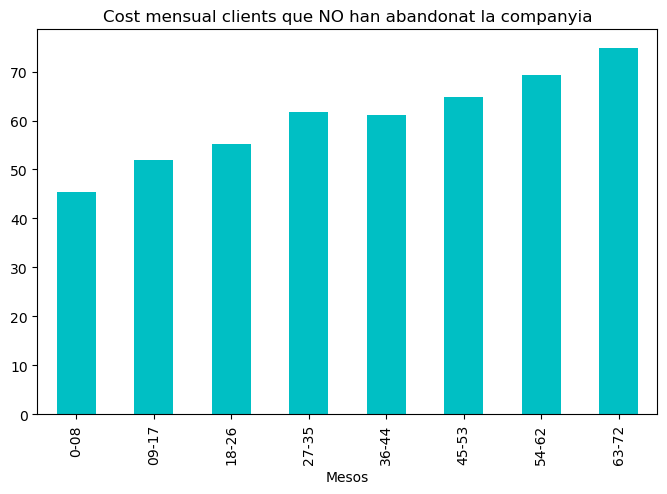

In [199]:
df_no_aband=df_aband[df_aband['Churn']=='No']
g2=df_no_aband.groupby('Franja__mesos_permanencia')
m_cost_no_aband=g2['MonthlyCharges'].mean()
m_cost_no_aband.plot(kind='bar', figsize=(8, 5), color='#00BFC4')
plt.title('Cost mensual clients que NO han abandonat la companyia')
plt.xlabel('Mesos')

>Com es pot apreciar, els dos grups segueixen la tendència de què en funció del temps, el preu mensual a pagar augmenta. Molt possiblement per l'augment de serveis contractats com s'ha demostrat anteriorment. Però l'interessant de veure aquí és que, el rang de preus que pagaven aquells clients que han abandonat la companyia està entre els 65 i 100 € mentre que aquells que continuen pagant entre 45 i 80 €. Amb aquestes dades podem dir que efectivament, el haver estar pagant preus elevats (en comparació amb els que no abandonen la companyia) durant molt de temps també indueix a la no permanència a la companyia de telecomunicacions.
>
>Una observació important és que els resultats obtinguts aquí són contraris als que amb l'estudi inicial vam obtenir. Això demostra l'importància d'aprofundir en els objectius i pensar en totes les possibles variables que poden influir. 